# Exercise 4

## Import packages

In [ ]:
import sys
import os

# Ensure repository root is on sys.path so local package imports (vll.*) work
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

from vll.utils.download import download_mnist

## Task 1
(3 points)

Implement the training loop for one training epoch.
An epoch trains on the whole training dataset once.

In [31]:
def train(model, use_cuda, train_loader, optimizer, epoch, log_interval):
    """
    Train one epoch
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    train_loader -- data loader
    optimizer -- network optimizer
    epoch -- number of current epoch
    log_interval -- number of training steps between logs
    """
    # set the model to train mode
    model.train()

    # enumerate over the dataloader to get mini batches
    # of images and ground truth labels
    for batch_idx, (data, target) in enumerate(train_loader):
        # transfer to GPU if requested
        if use_cuda:
            data = data.cuda()
            target = target.cuda()

        # set the optimizers gradients to zero
        optimizer.zero_grad()

        # run the network
        output = model(data)

        # compute negative log likelihood loss
        loss = F.nll_loss(output, target)

        # do backpropagation
        loss.backward()

        # optimize
        optimizer.step()

        # print current loss for every nth ("log_interval"th) iteration
        if batch_idx % log_interval == 0:
            processed = batch_idx * len(data)
            total = len(train_loader.dataset)
            percent = 100. * batch_idx / len(train_loader)
            print('Train Epoch: {} [{}/{} ({:.0f}%)]	Loss: {:.6f}'.format(
                epoch, processed, total, percent, loss.item()))

We already implemented the validation function for you (this is essentially validate() from the last exercise)

In [32]:
def validate(model, use_cuda, test_loader):
    """
    Compute test metrics
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    test_loader -- data loader
    """
    # create a 10x10 grid of subplots
    _, axis = plt.subplots(10, 10)
    
    # set model to evaluation mode
    model.eval()
    test_loss = 0
    correct = 0
    plotted = 0
    
    # disable gradients globally
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            # for each batch
            if use_cuda:
                # transfer to GPU
                data = data.cuda()
                target = target.cuda()
            
            # run network and compute metrics
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            
            img_correct = pred.eq(target.view_as(pred))
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            # plot the first 100 images
            img_idx = 0
            data = data.cpu().numpy()
            
            while plotted < 100 and img_idx < data.shape[0]:
                # compute position of ith image in the grid
                y = plotted % 10
                x = plotted // 10
                
                # convert image tensor to numpy array and normalize to [0, 1]
                img = data[img_idx, 0]
                img = (img - np.min(img)) / (np.max(img) - np.min(img))
                
                # make wrongly predicted images red
                img = np.stack([img] * 3, 2)
                if img_correct[img_idx] == 0:
                    img[:, :, 1:] = 0.0
                
                # disable axis and show image
                axis[y][x].axis('off')
                axis[y][x].imshow(img)
                
                # show the predicted class next to each image
                axis[y][x].text(30, 25, pred[img_idx].item())
                
                plotted += 1
                img_idx += 1
            
    test_loss /= len(test_loader.dataset)

    # show results
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    plt.show()

## Task 2
(4 points)

Implement a five-layer fully connected neural network.
The dimensions (without batch size) should change like this: 784->200->100->60->30->10
Use log softmax to compute the class predictions.

Run the code at the end of the notebook to train and validate your implementation.

### Task 2.1
* sigmoid non-linear activation function
* note that the last layer does not need an activation function!

### Task 2.2
* add a new class "FCNet2"
* replace sigmoid with ReLU

### Task 2.3
* add a new class "FCNet2"
* add batch normalization to the first and third layers (note the difference between 1D/2D/3D versions)


**NOTE:** The perfomance should improve slightly with each step. However, due to the random weight initialization applied by PyTorch, your results may vary a bit between trainings.

In [33]:
class FCNet1(nn.Module):
    """
    Fully Connected Neural Network
    
    Five fully connected layers with sigmoid non-linearity
    
    Dimensions
    784->200->100->60->30->10
    """
    def __init__(self):
        super(FCNet1, self).__init__()
        
        # initialize network layers
        self.fc1 = nn.Linear(28 * 28, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)
       

    def forward(self, x):
        # reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1)

        # run network layers with sigmoid activations
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        x = self.fc5(x)

        # compute log softmax over the output
        output = F.log_softmax(x, dim=1)

        return output

In [34]:
class FCNet2(nn.Module):
    def __init__(self):
        super(FCNet2, self).__init__()
        
        # fully connected layers
        self.fc1 = nn.Linear(28 * 28, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)

    def forward(self, x):
        # reshape input
        x = x.view(x.size(0), -1)

        # apply layers with ReLU activations
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)

        # log softmax output
        return F.log_softmax(x, dim=1)

In [35]:
class FCNet3(nn.Module):
    def __init__(self):
        super(FCNet3, self).__init__()
        
        # fully connected layers
        self.fc1 = nn.Linear(28 * 28, 200)
        self.bn1 = nn.BatchNorm1d(200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.bn3 = nn.BatchNorm1d(60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)
        
    def forward(self, x):
        # reshape input
        x = x.view(x.size(0), -1)

        # run network with batchnorm on first and third layers
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.fc2(x))
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)

        return F.log_softmax(x, dim=1)

## Task 3
(3 points)

Implement a convolutional neural network, consisting of two convolutional and two fully connected layers.
This time, the dimensions (without batch size) should change like this: 1x28x28->32x26x26->64x12x12->128->10

### Task 3.1
* two convolutional layers (kernel size 3)
* two fully-connected layers
* ReLU activation function

### Task 3.2
* add batch normalization to first convolutional and first fully connected layer

### Task 3.3
* use max pooling instead of stride to reduce the dimensions to 64x12x12

In [36]:
class ConvNet1(nn.Module):
    """
    Convolutional Neural Network

    Two convolutional layers and two fully connected layers

    Dimensions:
    1x28x28->32x26x26->64x12x12->128->10
    """
    def __init__(self):
        super(ConvNet1, self).__init__()

        # two convolutional layers (kernel size 3)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)   # 28 -> 26
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2)  # 26 -> 12 (with stride)

        # fully connected layers
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # run convolutional layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        # reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1)

        # run fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        # compute log softmax over the output
        return F.log_softmax(x, dim=1)

In [37]:
class ConvNet2(nn.Module):
    def __init__(self):
        super(ConvNet2, self).__init__()

        # convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)   # 28 -> 26
        self.bn1 = nn.BatchNorm2d(32)                  # batchnorm on first conv
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2)  # 26 -> 12

        # fully connected layers
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)              # batchnorm on first fc
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # conv + batchnorm + relu
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.conv2(x))

        # flatten
        x = x.view(x.size(0), -1)

        # fc + batchnorm + relu
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.fc2(x)

        return F.log_softmax(x, dim=1)

In [38]:
class ConvNet3(nn.Module):
    def __init__(self):
        super(ConvNet3, self).__init__()

        # convolutional layers (no stride on conv2; use max-pool to reduce dims)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)   # 28 -> 26
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)  # 26 -> 24

        # fully connected layers
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # conv layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        # use max pooling to reduce to 12x12
        x = F.max_pool2d(x, kernel_size=2, stride=2)  # 24 -> 12

        # flatten
        x = x.view(x.size(0), -1)

        # fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return F.log_softmax(x, dim=1)

MNIST is ready!
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.310818
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.474724
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.474724
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.328138
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.328138
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.144159
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.144159
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.190756
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.190756
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.179223
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.179223
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.138309
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.138309
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.190196
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.190196
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.073337
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.073337
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.079295
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.079295

Test set: Average loss: 0.1191, Accuracy

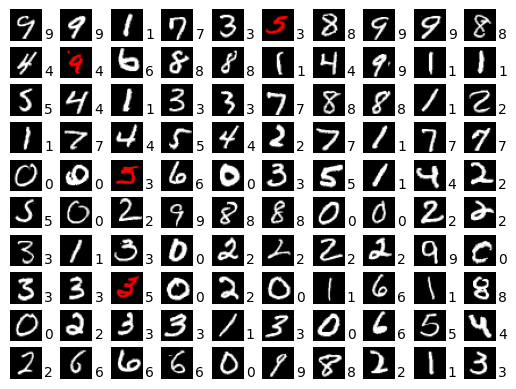

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.050349
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.058290
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.058290
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.088531
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.088531
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.009781
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.009781
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.076253
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.076253
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.046149
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.046149
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.143331
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.143331
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.050685
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.050685
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.050042
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.050042
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.032366
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.032366

Test set: Average loss: 0.0843, Accuracy: 9738/10000 (97

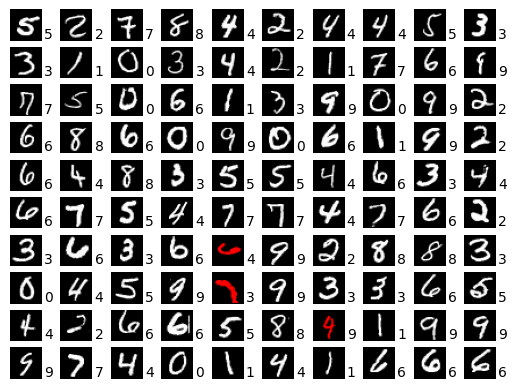

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.057895
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.134299
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.134299
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.006077
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.006077
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.143484
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.143484
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.091369
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.091369
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.004828
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.004828
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.106007
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.106007
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.050006
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.050006
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.001453
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.001453
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.185282
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.185282

Test set: Average loss: 0.0788, Accuracy: 9780/10000 (97

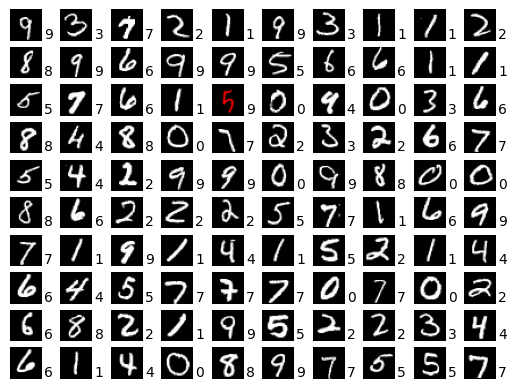

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.040755
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.016075
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.016075
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.051678
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.051678
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.004119
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.004119
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.034924
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.034924
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.001034
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.001034
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.034001
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.034001
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.042202
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.042202
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.001895
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.001895
Train Epoch: 4 [57600/60000 (96%)]	Loss: 0.001982
Train Epoch: 4 [57600/60000 (96%)]	Loss: 0.001982

Test set: Average loss: 0.0737, Accuracy: 9807/10000 (98

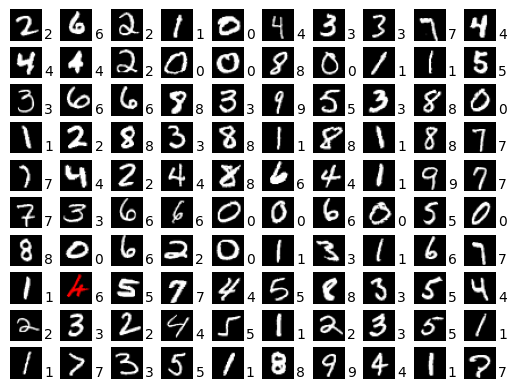

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.017077
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.017067
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.017067
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.080437
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.080437
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.016694
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.016694
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.005290
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.005290
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.001062
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.001062
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.088001
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.088001
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.166116
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.166116
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.075913
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.075913
Train Epoch: 5 [57600/60000 (96%)]	Loss: 0.000935
Train Epoch: 5 [57600/60000 (96%)]	Loss: 0.000935

Test set: Average loss: 0.0794, Accuracy: 9813/10000 (98

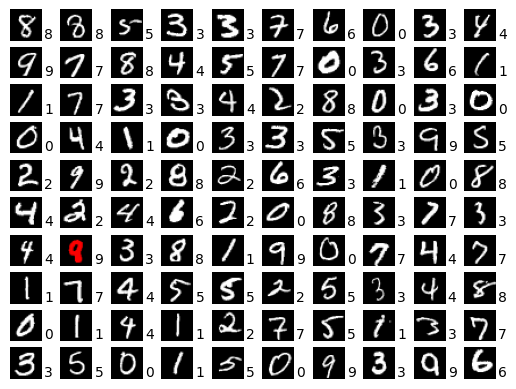

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.000046
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.000742
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.000742
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.000693
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.000693
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.006828
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.006828
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.000165
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.000165
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.000474
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.000474
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.032361
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.032361
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.000982
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.000982
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.001057
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.001057
Train Epoch: 6 [57600/60000 (96%)]	Loss: 0.015150
Train Epoch: 6 [57600/60000 (96%)]	Loss: 0.015150


In [ ]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# Ensure data-models directory exists inside the course data folder
import os
os.makedirs('data/mnist/models', exist_ok=True)

# --- Use project downloader and the course folder structure (data/mnist/...)
# Download MNIST as png folder-structure if not already present
download_mnist()

# initialize data loaders using the course dataset layout (training/testing folders)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.ImageFolder('data/mnist/training', transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **kwargs)

test_dataset = datasets.ImageFolder('data/mnist/testing', transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True, **kwargs)

model = FCNet2()
if use_cuda:
    model = model.cuda()

# initialize optimizer and scheduler
optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, epochs + 1):
    # train one epoch
    train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
    
    # run on test dataset
    validate(model, use_cuda, test_loader)
    scheduler.step()

    torch.save(model.state_dict(), "data/mnist/models/checkpoint.pt")